# 02 simulating multiple paths | simulate_paths()

a single path = one possible outcome; we want to sample a full distribution of outcomes

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
from gbm import simulate_paths

## new parameter

M = number of paths

In [2]:
Sof0  = 100
mu    = 0.08
sigma = 0.20
T     = 1.0
N     = int(252 * T)
M     = 1000 #this is sensible

paths = simulate_paths(Sof0, mu, sigma, T, N, M)
time  = np.linspace(0, T, N + 1)

print(f"paths shape: {paths.shape}")

paths shape: (253, 1000)


## fan chart

plotting all M paths

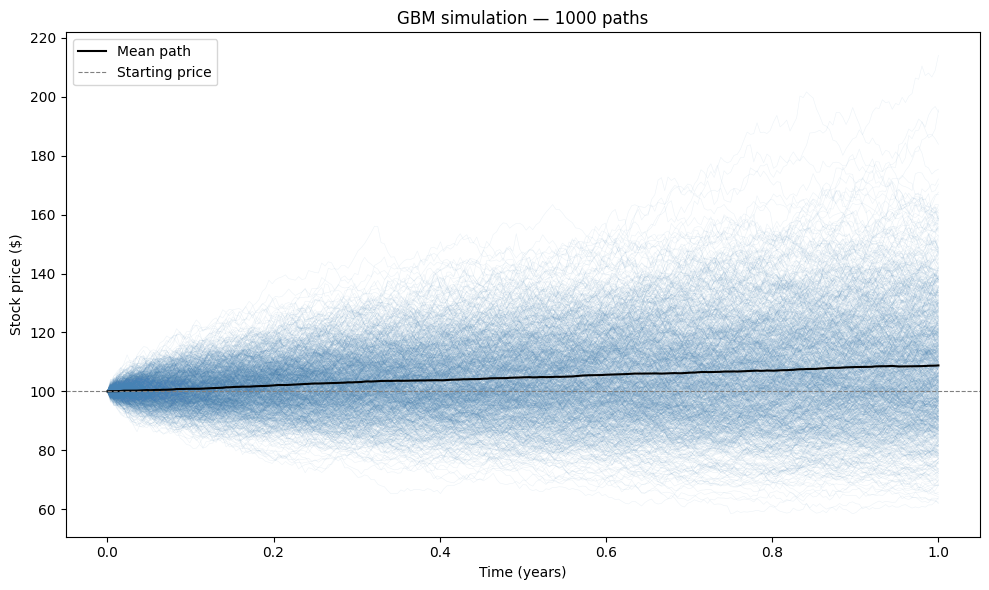

In [3]:
plt.figure(figsize=(10, 6))

# plot all paths with low opacity so overlaps show density
plt.plot(time, paths, color='steelblue', linewidth=0.4, alpha=0.1)

# overlay the mean path
plt.plot(time, paths.mean(axis=1), color='black', linewidth=1.5, label='Mean path')

plt.axhline(Sof0, color='gray', linestyle='--', linewidth=0.8, label='Starting price')
plt.xlabel('Time (years)')
plt.ylabel('Stock price ($)')
plt.title(f'GBM simulation — {M} paths')
plt.legend()
plt.tight_layout()
plt.show()

# distribution of final prices

histogram showing the distribution of prices at expiry T. notice that it is right-skewed as the distribution is log-normal.

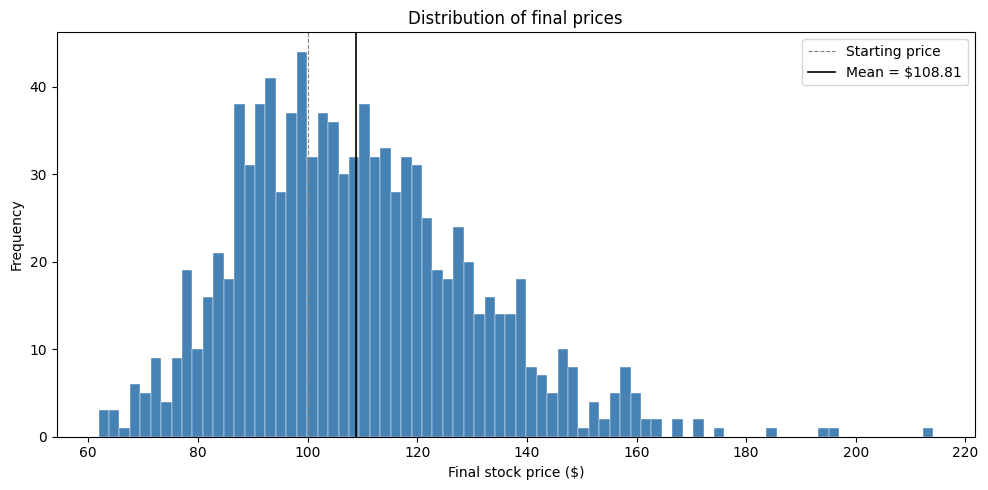

Mean final price : $108.81
Std dev          : $21.23
Min              : $61.89
Max              : $214.08


In [4]:
final_prices = paths[-1, :]  # last row = final price of every path

plt.figure(figsize=(10, 5))
plt.hist(final_prices, bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
plt.axvline(Sof0, color='gray', linestyle='--', linewidth=0.8, label='Starting price')
plt.axvline(final_prices.mean(), color='black', linewidth=1.2, label=f'Mean = ${final_prices.mean():.2f}')
plt.xlabel('Final stock price ($)')
plt.ylabel('Frequency')
plt.title('Distribution of final prices')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean final price : ${final_prices.mean():.2f}")
print(f"Std dev          : ${final_prices.std():.2f}")
print(f"Min              : ${final_prices.min():.2f}")
print(f"Max              : ${final_prices.max():.2f}")